# Monte Carlo Simulation for Fokker-Planck Equation with Metal.jl

In [ ]:
using Random, Base.Threads, Revise, Metal, Plots, ProgressMeter, Statistics, Roots, StatsBase

includet("MCKernel.jl")
using .MCKernel

includet("plot_helper.jl")
using .PlotHelper

In [27]:
using Pkg

# Get Julia version
julia_version = VERSION
println("Julia Version: ", julia_version)

# List of packages used in this notebook
used_packages = [
    "Random", "Revise", "Metal", "Plots", "ProgressMeter", 
    "Statistics", "Roots", "StatsBase", "CSV", "DataFrames", 
    "LinearAlgebra", "Colors"
]

# Get versions of used packages
println("Used Packages and Versions:")
for pkg_name in used_packages
    try
        Pkg.status(pkg_name)
    catch e
        println(pkg_name, ": Not installed")
    end
end


Julia Version: 1.11.3
Used Packages and Versions:
Status `~/.julia/environments/v1.11/Project.toml`
  [9a3f8284] Random v1.11.0
Status `~/.julia/environments/v1.11/Project.toml`
⌃ [295af30f] Revise v3.7.2
Info Packages marked with ⌃ have new versions available and may be upgradable.
Status `~/.julia/environments/v1.11/Project.toml`
  [dde4c033] Metal v1.5.1
Status `~/.julia/environments/v1.11/Project.toml`
⌃ [91a5bcdd] Plots v1.40.10
Info Packages marked with ⌃ have new versions available and may be upgradable.
Status `~/.julia/environments/v1.11/Project.toml`
  [92933f4c] ProgressMeter v1.10.2
Status `~/.julia/environments/v1.11/Project.toml`
  [10745b16] Statistics v1.11.1
Status `~/.julia/environments/v1.11/Project.toml`
  [f2b01f46] Roots v2.2.6
Status `~/.julia/environments/v1.11/Project.toml`
⌅ [2913bbd2] StatsBase v0.33.21
Info Packages marked with ⌅ have new versions available but compatibility constraints restrict them from upgrading. To see why use `status --outdated`
Status 

Julia Version: 1.11.3

Used Packages and Versions:

- Random v1.11.0
- Revise v3.7.2
- Metal v1.5.1
- Plots v1.40.10
- ProgressMeter v1.10.2
- Statistics v1.11.1
- Roots v2.2.6
- StatsBase v0.33.21
- CSV v0.10.15
- DataFrames v1.7.0
- LinearAlgebra v1.11.0
- Colors v0.12.11

## Example 1: Harmonic Measure on the Boundary of an Annulus 

The Kramers-Fokker-Planck equation is the generator of stochastic process modeling a particle's movement in a potential field. 
The stationary solution of the Fokker-Planck equation is the equilibrium distribution of the particle's position. The harmonic measure is a key concept in the study of the Fokker-Planck equation, representing the probability that a particle starting at a given point exits the domain through a given boundary.

In this notebook, we use Monte Carlo simulations to approximate solutions to equilibrium problems for the Fokker-Planck equation in various geometries.

### Example 1: Harmonic Measure on the Boundary of an Annulus

Consider the SDE:
$$
\left\{\begin{aligned}
    dX_t &= V_t dt, \\
    dV_t &= dB_t,
\end{aligned}\right.
$$
where $$B_t$$ is a standard Brownian motion. 
Denote by $z = (x, v)\in \mathbb{R}\times\mathbb{R}$. 
Its generator is given by:
$$
\mathcal{L} = \frac{1}{2}\frac{\partial^2}{\partial v^2} + v\frac{\partial}{\partial x}.
$$


We consider the process in the annulus 
$$A = \{z\in\mathbb{R}^2: r_{\text{inner}} < |z| < r_{\text{outer}}\}.$$

We simulate the process starting at the point $z_0 = (x_0, v_0)$ and compute the harmonic measure on the boundary of the annulus.

The Monte Carlo simulation involves:
- A Metal kernel function that updates the position of the particle according to the discretized SDE, namely
$$
x_{n+1} = x_n + v_n \Delta t, \quad v_{n+1} = v_n + \sqrt{\Delta t} \xi_n,
$$
where $$\xi_n \sim \mathcal{N}(0, 1)$$.
- Since the Metal kernel does not support random number generation, we also write an simple GPU friendly random number generator based on xorshift32 and box-muller method.
- The Kernel function does not support branching, the iteration will be fixed steps, and we use mask to stop the iteration when the particle hits the boundary.
- We simulate the process for a large number of particles and plot the harmonic measure on the boundary of the annulus.

In [2]:
inner_radius = 2.0f0
outer_radius = 4.0f0

4.0f0

In [3]:
# -------------------------
# Function: Equilibrium problem for KFP in an annulus
# -------------------------
function mc_annulus(start_point::Vector{Float32},
    num_trajectories::Int, time_step::Float32, num_steps::Int, inner_radius::Float32, outer_radius::Float32)

    # GPU arrays
    start_points = MtlArray(repeat(start_point, 1, num_trajectories))
    end_points = MtlArray(zeros(Float32, 2, num_trajectories))
    exit_flags = MtlArray(zeros(Bool, 2, num_trajectories))
    seeds = MtlArray(rand(UInt32, 2, num_trajectories))

    inner_radius2 = inner_radius^2
    outer_radius2 = outer_radius^2
    # Launch GPU kernel
    threads = 1024 # Default
    groups = cld(num_trajectories, threads)
    Metal.@sync begin
        @metal threads=threads groups=groups MCkernel_annulus(
        start_points, end_points, exit_flags, time_step, num_steps, seeds, inner_radius2, outer_radius2)
    end

    # Retrieve results
    end_points = Array(end_points)
    exit_flags = Array(exit_flags)
    # Compute exit values
    exit_values = zeros(Float32, num_trajectories)
    @threads for i in 1:num_trajectories
        if exit_flags[1, i]
            exit_values[i] = 1.0f0
        elseif exit_flags[2, i]
            exit_values[i] = 0.0f0
        else
            exit_values[i] = NaN
        end
    end

    # Find the indices where exit_values are not NaN
    valid_indices = findall(.!isnan.(exit_values))

    # Remove the corresponding entries from exit_values and end_points
    valid_values = exit_values[valid_indices]
    exit_points = end_points[:, valid_indices]

    exit_mean = sum(valid_values)/length(valid_values)

    return exit_mean, exit_points
end

mc_annulus (generic function with 1 method)

In [4]:
start_point = [3.0f0, -1.0f0]  # Single starting point
num_trajectories = 1024 * 100
time_step = 0.0001f0
num_steps = 200_000
# T = time_step * num_steps

@time exit_mean, exit_points = mc_annulus(start_point, num_trajectories, time_step, num_steps, inner_radius, outer_radius)

println("Exit values: ", exit_mean)

 13.834639 seconds (9.82 M allocations: 492.501 MiB, 0.33% gc time, 72.28% compilation time: 6% of which was recompilation)
Exit values: 0.73018557


┌ Warning: Keyword argument markerstrokestyle not supported with Plots.GRBackend().  Choose from: annotationcolor, annotationfontfamily, annotationfontsize, annotationhalign, annotationrotation, annotations, annotationvalign, arrow, aspect_ratio, axis, background_color, background_color_inside, background_color_outside, background_color_subplot, bar_width, bins, bottom_margin, camera, clims, color_palette, colorbar, colorbar_entry, colorbar_scale, colorbar_title, colorbar_titlefont, colorbar_titlefontcolor, colorbar_titlefontrotation, colorbar_titlefontsize, connections, contour_labels, discrete_values, fill, fill_z, fillalpha, fillcolor, fillrange, fillstyle, flip, fontfamily, fontfamily_subplot, foreground_color, foreground_color_axis, foreground_color_border, foreground_color_grid, foreground_color_subplot, foreground_color_text, formatter, framestyle, grid, gridalpha, gridlinewidth, gridstyle, group, guide, guidefont, guidefontcolor, guidefontfamily, guidefonthalign, guidefontrotat

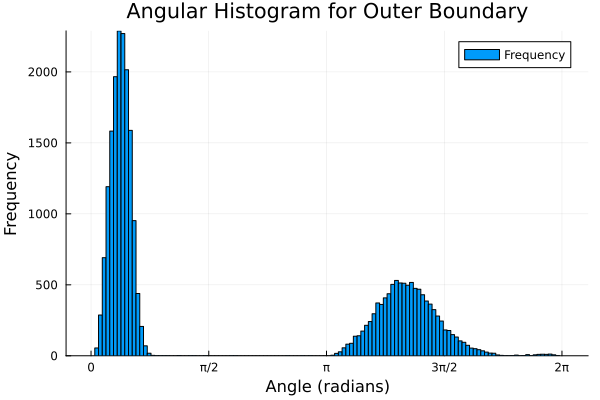

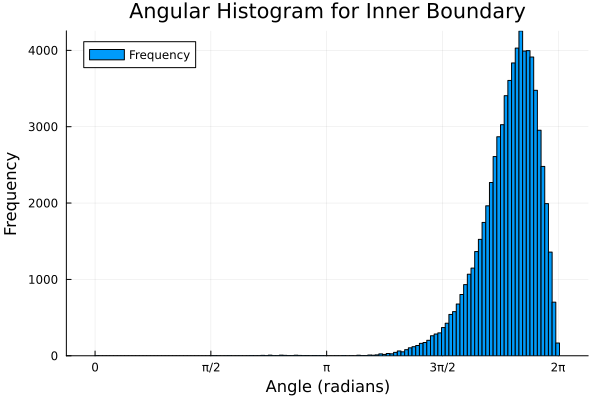

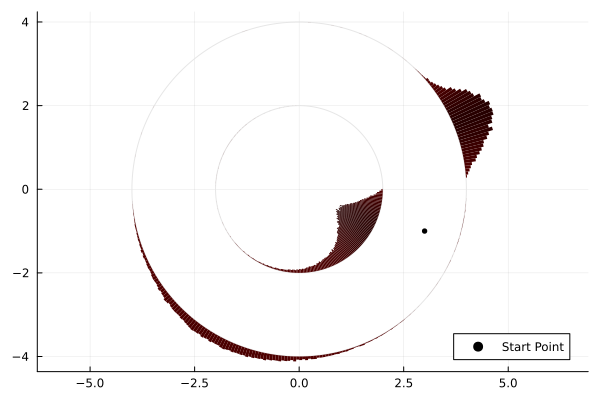

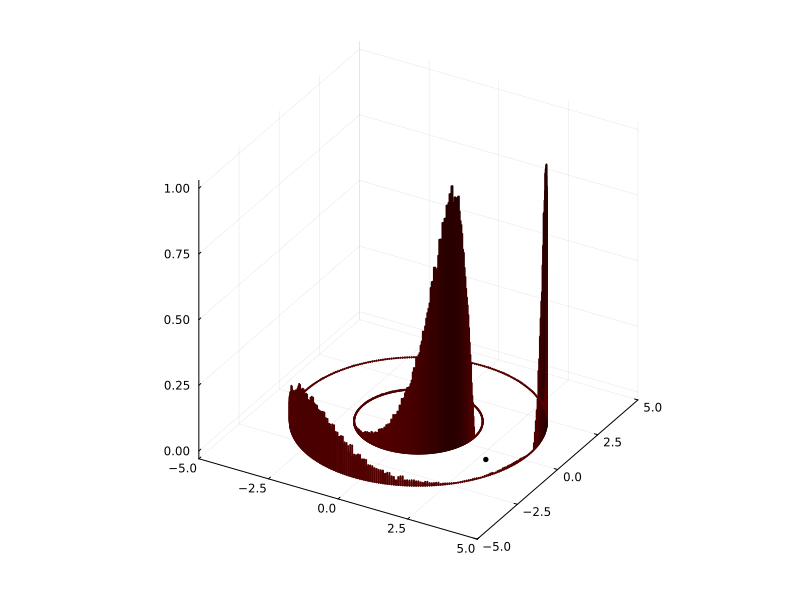

(Plot{Plots.GRBackend() n=1}, Plot{Plots.GRBackend() n=1}, Plot{Plots.GRBackend() n=723}, Plot{Plots.GRBackend() n=1443})

In [5]:
# Generate plots
_, _, plt3, plt4 = histogram_annulus(start_point, exit_points, inner_radius, outer_radius)

[ Info: Saved animation to /Users/mingyihou/Documents/GitHub/Monte_Carlo_KFP/tmp.gif


Plots.AnimatedGif("/Users/mingyihou/Documents/GitHub/Monte_Carlo_KFP/tmp.gif")
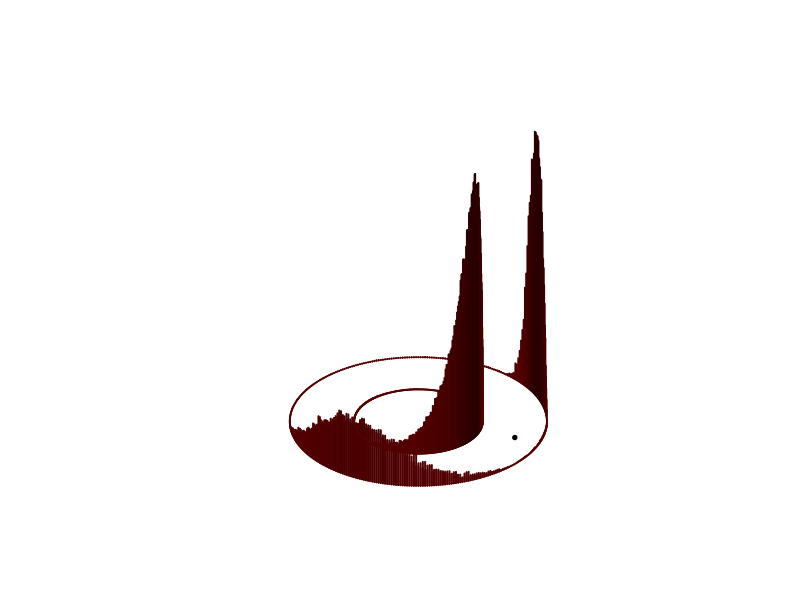

In [6]:
plot!(plt4, axis=false, grid=false)
@gif for azimuth in 0:1:360  # Rotate from 0° to 360° in steps of 1°
    plot3d!(plt4, camera=(azimuth, 30))  # Keep elevation at 30°
end every 1

## Example 2: Solution Near the Singular Set of a Square

In this example, we consider a square domain $Q := (-1, 1) \times (-1, 1)$ and compute the solution of a Dirichlet problem. Recall the operator given in Example 1, we consider the following Dirichlet problem:
$$
\left\{
\begin{aligned}
\mathcal{L} u(x, v) &= 0, \quad \text{in } Q, \\
u(x, v) &= g(x, v), \quad \text{on } \partial Q,
\end{aligned}
\right.
$$
where $g$ is the boundary value function. The boundary value is only attained on the regular part of the boundary, i.e., 
$$
(\{-1\}\times[-1, 0]) \cup ([-1, 1]\times\{-1\}) \cup (\{1\}\times[0, 1]) \cup ([-1, 1]\times\{1\}).
$$

The boundary value $g$ is defined as:
$$
g(x, v) = \left\{
\begin{aligned}
\varphi(2(v + 1/2)), \quad &\text{if } x = -1, \\
0, \quad &\text{if } v = -1, \\
\varphi(2(v - 1/2)), \quad &\text{if } x = 1, \\
0, \quad &\text{if } v = 1,
\end{aligned}
\right.
$$
where $\varphi$ is a smooth bump function:
$$
\phi(v) = \left\{
\begin{aligned}
\exp\left(-\frac{1}{1 - v^2}\right), \quad &\text{if } |v| < 1, \\
0, \quad &\text{otherwise}.
\end{aligned}
\right.
$$

The Monte Carlo simulation is almost the same as in Example 1. While the difference being that we also record the point before exit and the exit point.
Using both of them we can determine the exit point on the boundary and the value of the solution at that point.

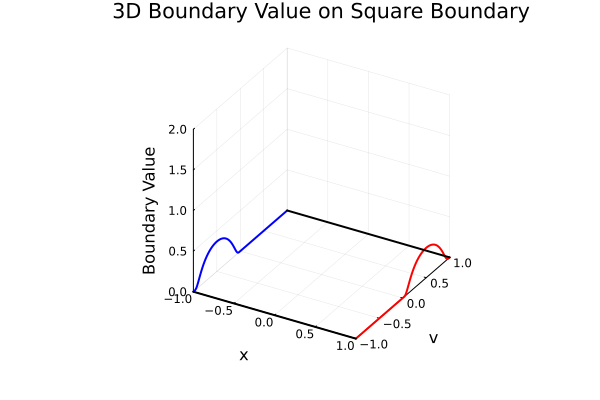

In [7]:
@inline function bump_function(x::Float64)
    return (-1.0 < x < 1.0) ? exp(-1.0 / (1.0 - x^2)) : 0.0
end

function boundary_value(point::Vector{Float32})
    x, v = point
    if v == 1.0 || v == -1.0
        return 0.0
    elseif x == -1.0
        return bump_function(2.0 * (v + 0.5))
    elseif x == 1.0
        return bump_function(2.0 * (v - 0.5))
    end
end

plot_boundary_value(boundary_value)

In [8]:
function mc_square(start_point::Vector{Float32},
    num_trajectories::Int, time_step::Float32, num_steps::Int)

    # GPU arrays
    start_points = MtlArray(repeat(start_point, 1, num_trajectories))
    end_points = MtlArray(zeros(Float32, 2, num_trajectories))
    points_before_end = MtlArray(zeros(Float32, 2, num_trajectories))
    exit_flags = MtlArray(zeros(Bool, 1, num_trajectories))
    seeds = MtlArray(rand(UInt32, 2, num_trajectories))

    # Launch GPU kernel
    threads = 1024 # Default
    groups = cld(num_trajectories, threads)
    Metal.@sync begin
        @metal threads=threads groups=groups MCkernel_square(start_points, end_points, exit_flags, time_step, num_steps, points_before_end, seeds)
    end

    # Retrieve results
    end_points = Array(end_points)
    points_before_end = Array(points_before_end)
    exit_flags = Array(exit_flags)

    # Define a function to compute the intersection of a line segment with the square boundary
    function line_segment_square_intersection(point_before_exit::Vector{Float32}, exit_point::Vector{Float32})
        x1, y1 = point_before_exit
        x2, y2 = exit_point
    
        # Define boundary conditions
        boundaries = [(1.0f0, :y), (-1.0f0, :y), (1.0f0, :x), (-1.0f0, :x)]
    
        for (boundary, axis) in boundaries
            if axis == :y && y1 != y2
                t = (boundary - y1) / (y2 - y1)
                x_int = x1 + t * (x2 - x1)
                if 0.0f0 <= t <= 1.0f0 && -1.0f0 <= x_int <= 1.0f0
                    return [x_int, boundary]
                end
            elseif axis == :x && x1 != x2
                t = (boundary - x1) / (x2 - x1)
                y_int = y1 + t * (y2 - y1)
                if 0.0f0 <= t <= 1.0f0 && -1.0f0 <= y_int <= 1.0f0
                    return [boundary, y_int]
                end
            end
        end
        return nothing  # Return nothing explicitly if no intersection is found
    end

    # Compute exit values
    exit_points = zeros(Float32, 2, num_trajectories)
    exit_values = zeros(Float32, num_trajectories)
    @threads for i in 1:num_trajectories
        if exit_flags[i]
            temp_result = line_segment_square_intersection(points_before_end[:, i], end_points[:, i])
            if temp_result !== nothing
                exit_points[:, i] .= temp_result  # Correctly assign tuple values to the array slice
                exit_values[i] = boundary_value(temp_result)
            else
                exit_points[:, i] .= NaN  # Assign NaNs if no intersection is found
                exit_values[i] = NaN
            end
        else
            exit_points[:, i] .= NaN  # Assign NaNs if not exited
            exit_values[i] = NaN
        end
    end

    # Find the indices where exit_values are not NaN
    valid_indices = findall(.!isnan.(exit_values))

    # Remove the corresponding entries from exit_values and end_points
    valid_values = exit_values[valid_indices]
    exit_points = exit_points[:, valid_indices]

    exit_mean = sum(valid_values)/length(valid_values)

    exit_rate = length(valid_values) / num_trajectories

    return exit_mean, exit_points, exit_rate
end

mc_square (generic function with 1 method)

In [9]:
start_point = [0.0f0, -0.5f0]  # Single starting point
num_trajectories = 1024 * 10
time_step = 0.0001f0
num_steps = 20_000
# T = time_step * num_steps

@time exit_mean, exit_points, exit_rate = mc_square(start_point, num_trajectories, time_step, num_steps)

println("Exit values: ", exit_mean)
println("Exit rate: ", exit_rate)

  0.446794 seconds (1.30 M allocations: 60.657 MiB, 2.74% gc time, 180.81% compilation time)
Exit values: 3.812381e-5
Exit rate: 0.9216796875


In [10]:
function Monte_Carlo(grid_points,
                    time_step,
                    num_trajectories,
                    num_steps)

    results = Dict{Vector{Float32}, Float32}()
    exit_rates = Dict{Vector{Float32}, Float64}()

    @inline function is_on_regular(point::Vector{Float32})::Bool
        x, v = point
        return (x == -1.0 && -1.0 ≤ v ≤ 0.0) ||
               (x == 1.0 && 0.0 ≤ v ≤ 1.0) ||
               (-1.0 ≤ x ≤ 1.0 && (v == 1.0 || v == -1.0))
    end

    @showprogress for start_point in grid_points
        if is_on_regular(start_point)
            results[start_point] = boundary_value(start_point)
            exit_rates[start_point] = 1.0
        else
            exit_mean, _, exit_rate = mc_square(start_point, num_trajectories, time_step, num_steps)
            results[start_point] = exit_mean
            exit_rates[start_point] = exit_rate
        end
    end

    return results, exit_rates
end

Monte_Carlo (generic function with 1 method)

In [29]:
num_trajectories = 1024 * 10
time_step = 0.001f0
num_steps = 5_000

# Create a uniform grid in [0, 1]
u = -1.0f0:0.05f0:1.0f0

x_values = cbrt.(u)  # Dense near -1 and 1
v_values = -1.0f0:0.02f0:1.0f0 

# Combine to form grid points
grid_points = [[x, v] for v in v_values, x in x_values]

results, exit_rates = Monte_Carlo(grid_points, time_step, num_trajectories, num_steps)

Progress: 100%|█████████████████████████████████████████| Time: 0:01:36


(Dict{Vector{Float32}, Float32}([0.9085603, -0.86] => 0.008649696, [-0.7937005, 0.44] => 0.022578027, [-1.0, 0.52] => 0.065370195, [-0.5848035, 0.66] => 0.0033454795, [0.7937005, 0.9] => 0.032661796, [-0.8193213, 0.88] => 0.004673236, [0.0, -0.8] => 0.00039933439, [0.98304754, 0.62] => 0.2970357, [-0.94726825, 0.4] => 0.06669242, [0.9085603, 0.92] => 0.059513547…), Dict{Vector{Float32}, Float64}([0.9085603, -0.86] => 0.99951171875, [-0.7937005, 0.44] => 0.9994140625, [-1.0, 0.52] => 0.99912109375, [-0.5848035, 0.66] => 0.99931640625, [0.7937005, 0.9] => 0.99990234375, [-0.8193213, 0.88] => 0.99951171875, [0.0, -0.8] => 0.99970703125, [0.98304754, 0.62] => 1.0, [-0.94726825, 0.4] => 0.998828125, [0.9085603, 0.92] => 1.0…))

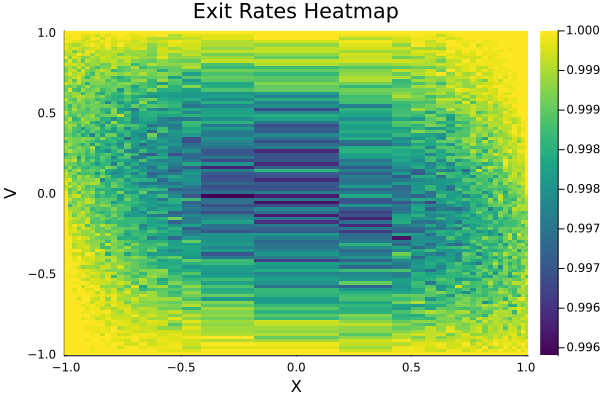

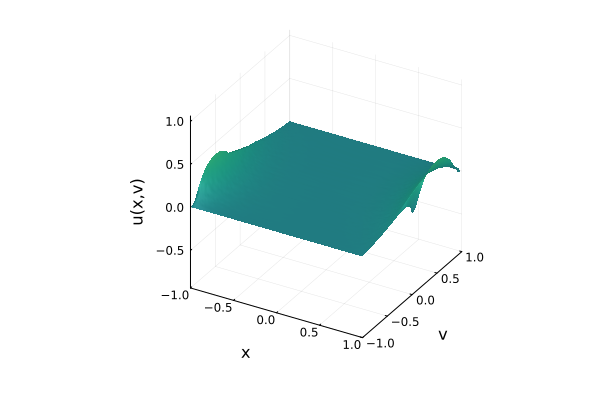

(Plot{Plots.GRBackend() n=1}, Plot{Plots.GRBackend() n=1})

In [30]:
_, plt_square = plot3d_square(x_values, v_values, grid_points, results, exit_rates)

In [31]:
savefig(plt_square, "square_boundary.png")

"/Users/mingyihou/Documents/GitHub/Monte_Carlo_KFP/square_boundary.png"

In [13]:
time_step = 0.0001f0
num_trajectories = 1024 * 12
num_steps = 10_000

# Create a uniform grid in [0, 1]
u = 0.9f0:0.002f0:1.0f0

x_values = cbrt.(u)  # Dense near -1 and 1
v_values = -0.05f0:0.002f0:0.05f0 

# Combine to form grid points
grid_points = [[x, v] for v in v_values, x in x_values]

results, exit_rates = Monte_Carlo(grid_points, time_step, num_trajectories, num_steps)

Progress: 100%|█████████████████████████████████████████| Time: 0:01:48


(Dict{Vector{Float32}, Float32}([0.97469854, -0.032] => 0.19778483, [0.9753998, -0.008] => 0.20463322, [0.97749746, -0.03] => 0.20033558, [0.96834165, -0.048] => 0.18781744, [0.96905214, -0.03] => 0.19420618, [0.98028034, -0.006] => 0.20626132, [0.97329307, 0.006] => 0.20812474, [0.9795861, 0.042] => 0.2214631, [0.97399634, 0.006] => 0.20951347, [0.9761, -0.004] => 0.20823309…), Dict{Vector{Float32}, Float64}([0.97469854, -0.032] => 0.8480631510416666, [0.9753998, -0.008] => 0.8545735677083334, [0.97749746, -0.03] => 0.85498046875, [0.96834165, -0.048] => 0.8341471354166666, [0.96905214, -0.03] => 0.8379720052083334, [0.98028034, -0.006] => 0.864013671875, [0.97329307, 0.006] => 0.8536783854166666, [0.9795861, 0.042] => 0.87548828125, [0.97399634, 0.006] => 0.8631184895833334, [0.9761, -0.004] => 0.8572591145833334…))

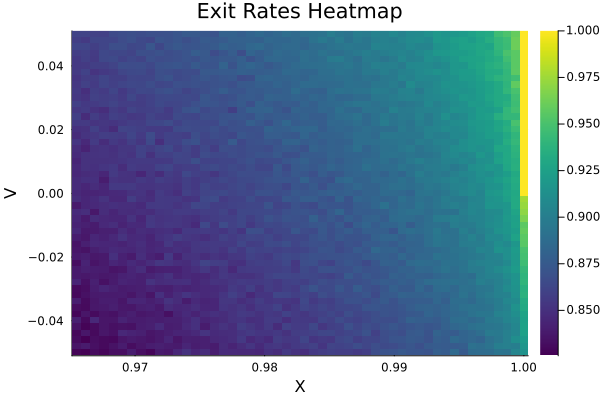

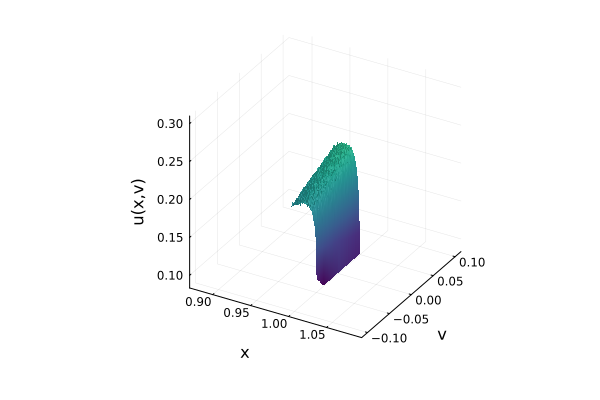

(Plot{Plots.GRBackend() n=1}, Plot{Plots.GRBackend() n=1})

In [14]:
plot3d_square(x_values, v_values, grid_points, results, exit_rates)

## Example 3: Harmonic Measure for the Equilibrium Problem of Kramers-Fokker-Planck Equation

In this example, we consider the following underdamped Langevin process:
$$
\left\{
\begin{aligned}
dX_t &= V_t dt, \\
dV_t &= -\nabla U(X_t) dt - \gamma V_t dt + \sqrt{\varepsilon} dW_t,
\end{aligned}
\right.
$$
where $U(x)$ is a potential function, $\gamma$ is the friction coefficient, $\varepsilon$ is the noise intensity, and $W_t$ is a standard Brownian motion.
Its generator is given by:
$$
\mathcal{L} = \frac{\varepsilon}{2} \partial^2_v - \gamma v\partial_v - \partial_x U \partial_v + v\partial_x.
$$

The discretized version of the process is:
$$
\left\{
\begin{aligned}
X_{n+1} &= X_n + V_n \Delta t, \\
V_{n+1} &= \alpha V_n - \nabla U(X_n) \Delta_t + \sqrt{\Delta_t} \xi_n,
\end{aligned}
\right.
$$
where $\xi_n$ is a standard normal random variable, and $\gamma = (1-\alpha)/\Delta_t$.

The potential is given by:
$$
U(x) = \frac{1}{4}(x^2 - 1)^2 + 0.1(x + 1),
$$

Consider two balls $B_1$ and $B_2$ centered at two local minima of $U$ with radius $r$. We simulate the process starting from the saddle point and compute the harmonic measure on the boundary of $B_1$ and $B_2$.

In [15]:
# Define the potential function
U(x::Float32) = (x^2 - 1.0f0)^2.0f0 / 4.0f0 + 0.1f0 * (x + 1)
grad(x::Float32) = (x^2 - 1.0f0) * (2.0f0 * x) / 2.0f0 + 0.1f0

grad (generic function with 1 method)

In [16]:
function mc_doublewell(start_point::Vector{Float32},
    num_trajectories::Int, time_step::Float32, num_steps::Int, grad, alpha::Float32, left_center_x::Float32, left_radius::Float32,  right_center_x::Float32, right_radius::Float32)

    # GPU arrays
    start_points = MtlArray(repeat(start_point, 1, num_trajectories))
    end_points = MtlArray(zeros(Float32, 2, num_trajectories))
    points_before_end = MtlArray(zeros(Float32, 2, num_trajectories))
    exit_flags = MtlArray(zeros(Bool, 2, num_trajectories))
    seeds = MtlArray(rand(UInt32, 2, num_trajectories))

    left_radius2 = left_radius^2
    right_radius2 = right_radius^2
    
    # Launch GPU kernel
    threads = 896 # Somehow, for this doublewell kernel, the resource usage is higher, and we need to reduce the number of threads
    groups = cld(num_trajectories, threads)
    Metal.@sync begin
        @metal threads=threads groups=groups MCkernel_doublewell(start_points, end_points, exit_flags, time_step, num_steps, points_before_end, seeds, alpha, grad, left_center_x, left_radius2, right_center_x, right_radius2)
    end

    # Retrieve results
    end_points = Array(end_points)
    exit_flags = Array(exit_flags)
    points_before_end = Array(points_before_end)

    # Compute exit values
    exit_values = zeros(Float32, num_trajectories)
    @threads for i in 1:num_trajectories
        if exit_flags[1, i]
            exit_values[i] = 0.0f0
        elseif exit_flags[2, i]
            exit_values[i] = 1.0f0
        else
            exit_values[i] = NaN
        end
    end

    # Find the indices where exit_values are not NaN
    valid_indices = findall(.!isnan.(exit_values))

    # Remove the corresponding entries from exit_values and end_points
    valid_values = exit_values[valid_indices]
    # exit_points = end_points[:, valid_indices]
    valid_end_points = end_points[:, valid_indices]
    valid_points_before_end = points_before_end[:, valid_indices]

    function line_segment_circle_intersection(p1::Vector{Float32}, p2::Vector{Float32}, center::Vector{Float32}, radius::Float32)
        x1, v1 = p1
        x2, v2 = p2
        xc, vc = center
    
        # Direction of the line segment
        dx = x2 - x1
        dv = v2 - v1
    
        # Quadratic equation coefficients
        A = dx^2 + dv^2
        B = 2 * ((x1 - xc) * dx + (v1 - vc) * dv)
        C = (x1 - xc)^2 + (v1 - vc)^2 - radius^2
    
        # Solve for t using the quadratic formula
        discriminant = B^2 - 4 * A * C
    
        if discriminant < 0
            return nothing  # No real intersection
        end
    
        sqrt_disc = sqrt(discriminant)
        t1 = (-B - sqrt_disc) / (2 * A)
        t2 = (-B + sqrt_disc) / (2 * A)
    
        # Find the valid intersection in the range t ∈ [0,1]
        t_valid = filter(t -> 0.0 <= t <= 1.0, [t1, t2])
    
        if isempty(t_valid)
            return nothing  # No valid intersection on the segment
        end
    
        # Compute the intersection point(s)
        intersections = [[x1 + t * dx, v1 + t * dv] for t in t_valid]
    
        return intersections
    end

    exit_points = zeros(Float32, 2, length(valid_indices))
    @threads for i in 1:size(valid_end_points, 2)
        if exit_flags[1, valid_indices[i]]
            temp_result = line_segment_circle_intersection(valid_points_before_end[:, i], valid_end_points[:, i], [left_center_x, 0.0f0], left_radius)
            if temp_result !== nothing
                exit_points[:, i] .= temp_result[1]  # Correctly assign tuple values to the array slice
            end
        elseif exit_flags[2, valid_indices[i]]
            temp_result = line_segment_circle_intersection(valid_points_before_end[:, i], valid_end_points[:, i], [right_center_x, 0.0f0], right_radius)
            if temp_result !== nothing
                exit_points[:, i] .= temp_result[1]  # Correctly assign tuple values to the array slice
            end
        end
    end
    

    exit_mean = sum(valid_values)/length(valid_values)
    exit_rate = length(valid_values) / num_trajectories

    return exit_mean, exit_points, exit_rate
end

mc_doublewell (generic function with 1 method)

In [17]:
left_min, saddle, right_min = find_zeros(grad, (-2.0f0, 2.0f0))

left_center_x = left_min
right_center_x = right_min

radius = 0.5f0
left_radius = radius
right_radius = radius

start_point = [saddle, 0.0f0]  # Single starting point
num_trajectories = 1024 * 10_000
time_step = 0.008f0
num_steps = 10_000
alpha = 0.995f0

@time exit_mean, exit_points, exit_rate = mc_doublewell(start_point, num_trajectories, time_step, num_steps, grad, alpha, left_center_x, left_radius, right_center_x, right_radius)

println("Exit values: ", exit_mean)
println("Exit rate: ", exit_rate)

 22.763783 seconds (185.73 M allocations: 5.960 GiB, 2.90% gc time, 3.18% compilation time)
Exit values: 0.5332127
Exit rate: 1.0


In [18]:
using CSV, DataFrames

# Convert to DataFrame and save as CSV
df = DataFrame(exit_points', :auto)  # Transpose to n × 2 for proper CSV format
CSV.write("exit_points.csv", df)     # Save for post-processing

"exit_points.csv"

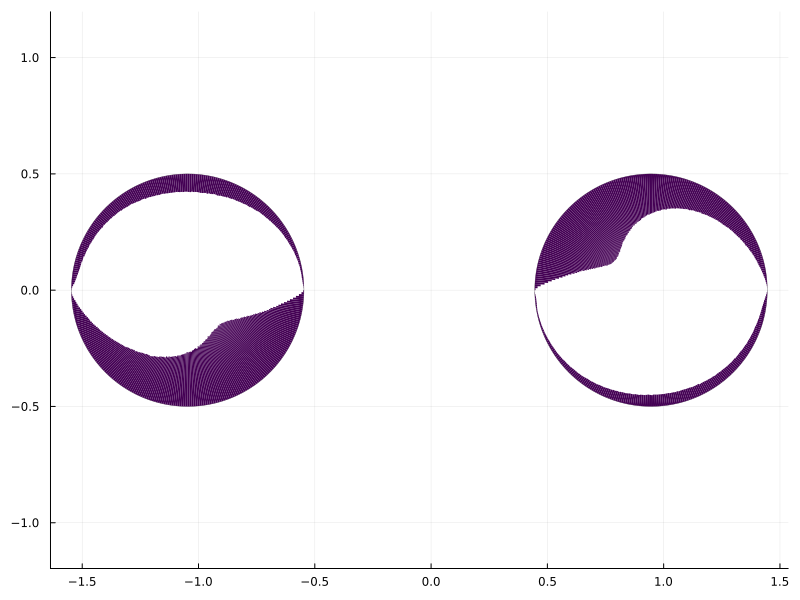

In [19]:
# Separate exit points into right and left based on x-coordinate.
right_exits = [exit_points[:, i] for i in 1:size(exit_points, 2) if exit_points[1, i] >= 0]
left_exits  = [exit_points[:, i] for i in 1:size(exit_points, 2) if exit_points[1, i] < 0]

# Function to convert (x, v) exit points into polar angles relative to a given center
function angles_from_points(points, center)
    return [mod(atan(p[2]-center[2], p[1]-center[1]), 2π) for p in points]
end

angles_right = angles_from_points(right_exits, [right_center_x, 0.0])
angles_left  = angles_from_points(left_exits, [left_center_x, 0.0])

# Build histograms for each target's angular distribution
num_bins = 360
bin_edges = collect(range(0, stop=2π, length=num_bins+1))
hist_right = fit(Histogram, angles_right, bin_edges)
hist_left  = fit(Histogram, angles_left, bin_edges)

# Extract bin centers and frequencies
bin_centers = [(bin_edges[i] + bin_edges[i+1]) / 2 for i in 1:length(bin_edges)-1]
freq_right = hist_right.weights / maximum(hist_right.weights)
freq_left  = hist_left.weights / maximum(hist_left.weights)

# Scale factors for bar thickness
scale_factor = 0.3  # Adjust as needed
bar_thickness_right = scale_factor .* freq_right
bar_thickness_left  = scale_factor .* freq_left

# Generate target circles for right and left targets
θ = range(0, stop=2π, length=100)
circle_right_x = right_center_x .+ radius * cos.(θ)
circle_right_y = 0.0 .+ radius * sin.(θ)
circle_left_x  = left_center_x .+ radius * cos.(θ)
circle_left_y  = 0.0 .+ radius * sin.(θ)

p = plot(circle_right_x, circle_right_y, lw=0.5, linecolor=:grey, label=false, aspect_ratio=1, size=(800, 600))
plot!(p, circle_left_x, circle_left_y, lw=0.5, linecolor=:grey, label=false)

# Function to create a filled arc polygon given center, base radius, bar thickness, and angular span.
# Bars extend outward: outer radius = base_radius + thickness.
function plot_arc_segment!(p, center, base_radius, angle_start, angle_end, thickness, color)
    npts = 20
    inner_arc = [(center[1] + base_radius*cos(t), center[2] + base_radius*sin(t))
                 for t in range(angle_start, angle_end, length=npts)]
    outer_arc = [(center[1] + (base_radius - thickness)*cos(t), center[2] + (base_radius - thickness)*sin(t))
                 for t in range(angle_end, angle_start, length=npts)]
    poly_points = vcat(inner_arc, outer_arc)
    xs = first.(poly_points)
    ys = last.(poly_points)
    plot!(p, xs, ys, seriestype=:shape, fillcolor=color, linecolor=:transparent, label=false)
end

# Plot histogram arcs for the right target
for i in 1:length(bin_centers)
    angle_start = bin_edges[i]
    angle_end   = bin_edges[i+1]
    # brightness = 1 - freq_right[i] / (maximum(freq_right) + eps())
    # color = RGB(0, 0, brightness)
    plot_arc_segment!(p, (right_center_x, 0.0), radius, angle_start, angle_end, bar_thickness_right[i], :viridis)
end

# Plot histogram arcs for the left target
for i in 1:length(bin_centers)
    angle_start = bin_edges[i]
    angle_end   = bin_edges[i+1]
    # brightness = 1 - freq_left[i] / (maximum(freq_left) + eps())
    # color = RGB(0, 0, brightness)
    plot_arc_segment!(p, (left_center_x, 0.0), radius, angle_start, angle_end, bar_thickness_left[i], :viridis)
end

display(p)